# Initial Work

In [1]:
import pandas as pd
import numpy as np

In [2]:
target_column = ['First_Round_Interviews','Second_Round_Interviews','Offer_Received']

## Read the Data

In [3]:
df=pd.read_csv('../data/job_search_platform_efficacy_100k.csv')
df.head(20)

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN
5,STU_000006,Mid-tier,Large,Midwest,Business,4.00,0,4,1,Handshake,2,6,0,0,0,NaN,NaN,NaN,NaN,NaN
6,STU_000007,Top-tier,Large,West,STEM,3.28,2,0,7,Handshake,10,20,0,0,0,NaN,NaN,NaN,NaN,NaN
7,STU_000008,Lower-tier,Large,West,Business,2.62,2,3,7,LinkedIn,10,76,3,0,0,NaN,NaN,NaN,NaN,NaN
8,STU_000009,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1,31.0,69910.0,Mid-Size,7.0,1.0
9,STU_000010,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1,38.0,73669.0,Startup,1.0,1.0


In [4]:
print(df.Accepted_Offer.value_counts(dropna=False))
print(df.Role_Relevance.value_counts(dropna=False))
print(df.Company_Size_Offered.value_counts(dropna=False))
print(df.Time_to_Offer_Days.value_counts(dropna=False))

Accepted_Offer
NaN    65771
1.0    27445
0.0     6784
Name: count, dtype: int64
Role_Relevance
NaN     65771
8.0      6500
7.0      5921
6.0      5038
9.0      4778
10.0     3744
5.0      3307
4.0      2115
3.0      1290
2.0       778
1.0       758
Name: count, dtype: int64
Company_Size_Offered
NaN           65771
Enterprise    13908
Mid-Size      13623
Startup        6698
Name: count, dtype: int64
Time_to_Offer_Days
NaN     65771
41.0      833
43.0      822
33.0      813
32.0      811
        ...  
14.0      201
19.0      200
16.0      193
17.0      184
18.0      183
Name: count, Length: 77, dtype: int64


## Data Cleaning

In [5]:
df_clean = df.drop(columns=['Student_ID','Offer_Salary','Company_Size_Offered','Role_Relevance','Accepted_Offer','Time_to_Offer_Days'])
df_clean.head(20)


,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
0,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1
1,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0
2,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0
3,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0
4,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0
5,Mid-tier,Large,Midwest,Business,4.00,0,4,1,Handshake,2,6,0,0,0
6,Top-tier,Large,West,STEM,3.28,2,0,7,Handshake,10,20,0,0,0
7,Lower-tier,Large,West,Business,2.62,2,3,7,LinkedIn,10,76,3,0,0
8,Mid-tier,Medium,Northeast,STEM,3.01,0,3,2,Handshake,7,19,2,1,1
9,Lower-tier,Medium,West,STEM,3.22,2,1,1,Indeed,6,67,2,1,1


In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   University_Rating            100000 non-null  object 
 1   School_Size                  100000 non-null  object 
 2   Region                       100000 non-null  object 
 3   Major_Category               100000 non-null  object 
 4   GPA                          100000 non-null  float64
 5   Prior_Internships            100000 non-null  int64  
 6   Extra_Curricular_Activities  100000 non-null  int64  
 7   Networking_Events_Attended   100000 non-null  int64  
 8   Primary_Search_Platform      100000 non-null  object 
 9   Months_Searching             100000 non-null  int64  
 10  Applications_Submitted       100000 non-null  int64  
 11  First_Round_Interviews       100000 non-null  int64  
 12  Second_Round_Interviews      100000 non-null  int64  
 13  

In [18]:
print(df.duplicated().sum())
df_clean.describe()

0


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,3.196631,1.19697,2.003990,2.998600,6.499680,53.727620,2.16766,1.011640,0.342290
std,0.392370,1.12192,1.413709,1.734494,3.443719,45.004663,1.91176,1.138507,0.474478
min,2.000000,0.00000,0.000000,0.000000,1.000000,5.000000,0.00000,0.000000,0.000000
25%,2.930000,0.00000,1.000000,2.000000,4.000000,19.000000,1.00000,0.000000,0.000000
50%,3.200000,1.00000,2.000000,3.000000,6.000000,42.000000,2.00000,1.000000,0.000000
75%,3.470000,2.00000,3.000000,4.000000,9.000000,75.000000,3.00000,2.000000,1.000000
max,4.000000,5.00000,11.000000,14.000000,12.000000,300.000000,21.00000,12.000000,1.000000


## Preprocessing

### Create a 4-class Target Variable

> Created by Yueqiao\
> Modified by Mingkun Fu on 5/9

This will make it to a classification problem

In [ ]:
#def create_target(row):
#    if row['Offer_Received'] == 1:
#        return 3  # Got Offer
#    elif row['Second_Round_Interviews'] > 0:
#        return 2  # Second Round Interview but No Offer
#    elif row['First_Round_Interviews'] > 0:
#        return 1  # Interview but No Offer
#    else:
#        return 0  # No Interview
#    
#def return_target(num):
#    if num == 3:
#        return 'Got Offer'
#    elif num == 2:
#        return 'Second Round Interview but No Offer'
#    elif num == 1:
#        return 'Interview but No Offer'
#    else:
#        return 'No Interview'
#
#df_clean['application_result'] = df_clean.apply(create_target, axis=1)
#df_clean.drop(columns=target_column, inplace=True)
#df_clean.head(2)
#
#y = df_clean['application_result']
#X = df_clean.drop(columns=['application_result'])
#
#print("The distribution of the target variable:")
#print(y.value_counts())

The distribution of the target variable:
application_result
3    34229
2    24543
1    20666
0    20562
Name: count, dtype: int64


In [6]:
y=df_clean['Offer_Received']
X=df_clean.drop(columns=['Offer_Received'])
print("The distribution of the target variable:")
print(y.value_counts())

The distribution of the target variable:
Offer_Received
0    65771
1    34229
Name: count, dtype: int64


### Divide to Numberic and Categorical
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [7]:
X_numeric = X.select_dtypes(include=[np.number])
print("Numeric columns:")
X_numeric_columns = X_numeric.columns
print(X_numeric.columns)
X_numeric.head(1)

Numeric columns:
Index(['GPA', 'Prior_Internships', 'Extra_Curricular_Activities',
       'Networking_Events_Attended', 'Months_Searching',
       'Applications_Submitted', 'First_Round_Interviews',
       'Second_Round_Interviews'],
      dtype='object')


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews
0,2.81,3,2,6,1,9,2,2


In [8]:
X_categorical = X.select_dtypes(include=['object', 'string'])
print("\nCategorical columns:")
print(X_categorical.columns)
X_categorical.head(1)


Categorical columns:
Index(['University_Rating', 'School_Size', 'Region', 'Major_Category',
       'Primary_Search_Platform'],
      dtype='object')


,University_Rating,School_Size,Region,Major_Category,Primary_Search_Platform
0,Mid-tier,Medium,West,Healthcare,LinkedIn


### One Hot Encode Categorical Data
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [9]:
X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)
X_categorical_encoded.head(1)

,University_Rating_Mid-tier,University_Rating_Top-tier,School_Size_Medium,School_Size_Small,Region_Northeast,Region_South,Region_West,Major_Category_Business,Major_Category_Healthcare,Major_Category_Humanities,Major_Category_STEM,Primary_Search_Platform_Indeed,Primary_Search_Platform_LinkedIn
0,True,False,True,False,False,False,True,False,True,False,False,False,True


### Train Test Split
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [10]:
from sklearn.model_selection import train_test_split
X_temp = pd.concat([X_numeric, X_categorical_encoded], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y, test_size=0.2, stratify=y, random_state=0)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (80000, 21)
Test set shape: (20000, 21)


### StandardScaler
> Created by Mingkun on Apr 29;\
> Modified by Yueqiao on Apr 30

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


X_train_numeric_scaled = scaler.fit_transform(X_train[X_numeric_columns])
X_test_numeric_scaled = scaler.transform(X_test[X_numeric_columns])


X_train_categorical = X_train.drop(columns=X_numeric_columns)
X_test_categorical = X_test.drop(columns=X_numeric_columns)

X_train = pd.concat([
    pd.DataFrame(X_train_numeric_scaled, columns=X_numeric_columns),
    X_train_categorical.reset_index(drop=True)
], axis=1)

X_test = pd.concat([
    pd.DataFrame(X_test_numeric_scaled, columns=X_numeric_columns),
    X_test_categorical.reset_index(drop=True)
], axis=1)


### Post-preprocessing Analysis
> Created by Yueqiao on May 1\
>Modified by Mingkun Fu on 5/9

In [26]:
print(X_train.shape)
print(X_test.shape)

(80000, 21)
(20000, 21)


In [27]:
X_train.head(1)

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,University_Rating_Mid-tier,University_Rating_Top-tier,...,School_Size_Small,Region_Northeast,Region_South,Region_West,Major_Category_Business,Major_Category_Healthcare,Major_Category_Humanities,Major_Category_STEM,Primary_Search_Platform_Indeed,Primary_Search_Platform_LinkedIn
0,0.285332,0.716016,-1.418664,0.574869,1.304957,4.82096,-0.087251,-0.888804,True,False,...,False,True,False,False,False,False,False,True,True,False


In [28]:
X_train.describe()

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews
count,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04,8.000000e+04
mean,4.362732e-16,1.023182e-16,1.418421e-16,6.821210e-17,-1.492140e-17,-8.064660e-17,5.506706e-17,-4.085621e-17
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-3.051887e+00,-1.066421e+00,-1.418664e+00,-1.730427e+00,-1.600978e+00,-1.083266e+00,-1.136026e+00,-8.888044e-01
25%,-6.827164e-01,-1.066421e+00,-7.120571e-01,-5.777792e-01,-7.291971e-01,-7.503212e-01,-6.116387e-01,-8.888044e-01
50%,5.107410e-03,-1.752025e-01,-5.449709e-03,-1.455218e-03,1.425833e-01,-2.620017e-01,-8.725147e-02,-1.011590e-02
75%,6.929312e-01,7.160164e-01,7.011577e-01,5.748688e-01,7.237703e-01,4.704775e-01,4.371357e-01,8.685726e-01
max,2.043104e+00,3.389673e+00,5.647409e+00,6.338109e+00,1.595551e+00,5.464654e+00,9.876105e+00,9.655458e+00


In [ ]:
print("Class distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Class distribution in training set:
Offer_Received
0    52617
1    27383
Name: count, dtype: int64

Class distribution in test set:
Offer_Received
0    13154
1     6846
Name: count, dtype: int64


Text(0.5, 1.0, 'Target Distribution (Test Set)')

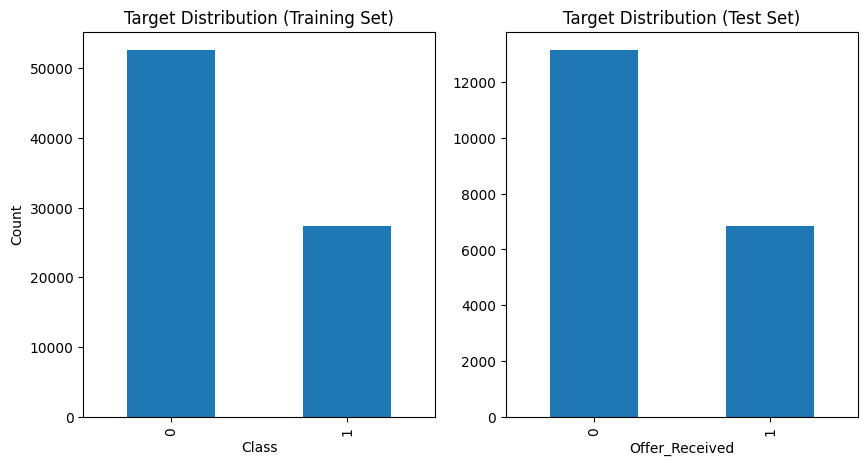

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar')
plt.title('Target Distribution (Training Set)')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind='bar')
plt.title('Target Distribution (Test Set)')

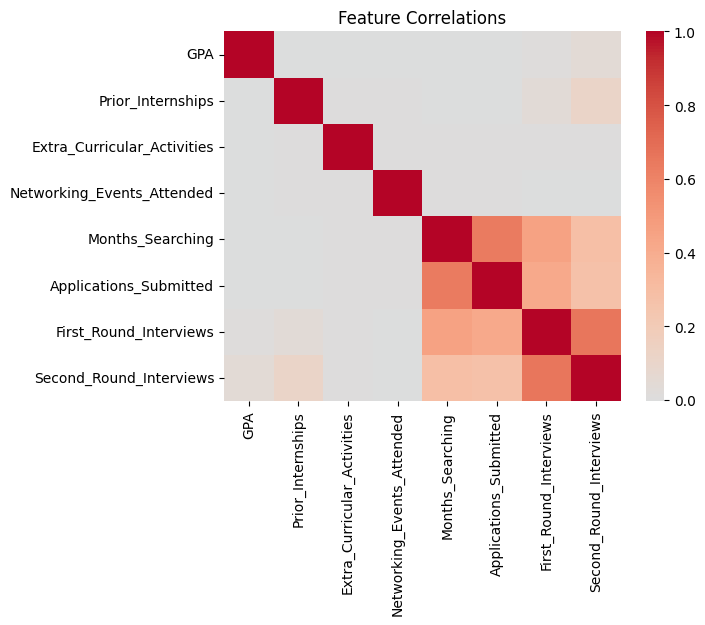

In [31]:

import seaborn as sns
sns.heatmap(X_numeric.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

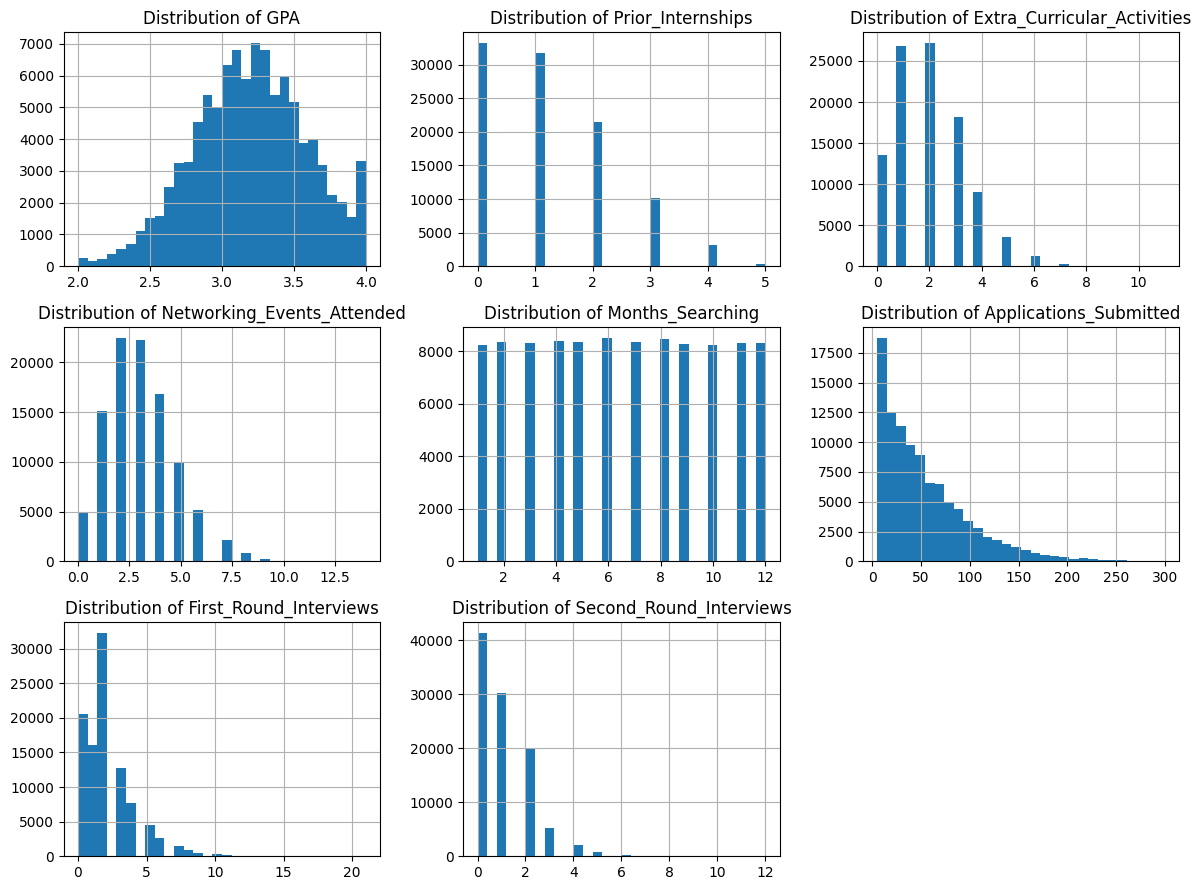

In [33]:
n_cols = 3
n_features = len(X_numeric.columns)
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, X_numeric.columns):
    X_numeric[col].hist(bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')

for ax in axes[n_features:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## BaseLine
> Created by Yueqiao on Apr 30

In [15]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

### Most Frequent Class

In [35]:
most_frequent_class = y_train.value_counts().idxmax()
print(f"Most frequent class in training set: {return_target(most_frequent_class)}")
y_pred_baseline = np.full(len(y_test), most_frequent_class)
classification_rep = classification_report(y_test, y_pred_baseline)
print("Baseline Classification Report:")
print(classification_rep)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy (Most Frequent): {baseline_accuracy:.4f}")

Most frequent class in training set: No Interview
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.66      1.00      0.79     13154
           1       0.00      0.00      0.00      6846

    accuracy                           0.66     20000
   macro avg       0.33      0.50      0.40     20000
weighted avg       0.43      0.66      0.52     20000

Baseline Accuracy (Most Frequent): 0.6577


e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

## Initial Models
> Created by Yueqiao on Apr 30\
>Modified by Mingkun Fu on 5/9

### KNN Classifier

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_grid = {
    'n_neighbors': np.arange(3, 32, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
knnCV = GridSearchCV(
    knn,
    param_grid=knn_grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
knnCV.fit(X_train, y_train)

print('best param:', knnCV.best_params_)
print('best valid accuracy:', round(knnCV.best_score_, 4))

best param: {'metric': 'manhattan', 'n_neighbors': np.int64(31), 'weights': 'distance'}
best valid accuracy: 0.8766


In [22]:
knn = knnCV.best_estimator_
y_pred_knn = knn.predict(X_test)
knn_classification_rep = classification_report(y_test, y_pred_knn)
print("Tuned KNN Classification Report:")
print(knn_classification_rep)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Tuned KNN Accuracy: {knn_accuracy:.4f}")

Tuned KNN Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90     13154
           1       0.80      0.85      0.82      6846

    accuracy                           0.88     20000
   macro avg       0.86      0.87      0.86     20000
weighted avg       0.88      0.88      0.88     20000

Tuned KNN Accuracy: 0.8766


### Simple Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
logreg_classification_rep = classification_report(y_test, y_pred_logreg)
print("Logistic Regression Classification Report:")
print(logreg_classification_rep)
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86     13154
           1       0.75      0.62      0.68      6846

    accuracy                           0.80     20000
   macro avg       0.79      0.76      0.77     20000
weighted avg       0.80      0.80      0.80     20000

Logistic Regression Accuracy: 0.8018


In [38]:
coef = logreg.coef_[0]
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coef
}).sort_values('coefficient', ascending=False)

print("Most important features (Logistic Regression):")
print(feature_importance.head(20))

Most important features (Logistic Regression):
                             feature  coefficient
7            Second_Round_Interviews     2.244295
1                  Prior_Internships     0.469798
0                                GPA     0.201729
9         University_Rating_Top-tier     0.152621
15           Major_Category_Business     0.077847
17         Major_Category_Humanities     0.068686
20  Primary_Search_Platform_LinkedIn     0.059378
18               Major_Category_STEM     0.043269
16         Major_Category_Healthcare     0.039077
3         Networking_Events_Attended     0.017225
11                 School_Size_Small     0.012619
2        Extra_Curricular_Activities     0.009425
13                      Region_South     0.008663
14                       Region_West    -0.000610
8         University_Rating_Mid-tier    -0.002728
10                School_Size_Medium    -0.011284
4                   Months_Searching    -0.033142
12                  Region_Northeast    -0.034549
19 

## Adding Regularization to Logistic regression
> Created by Mingkun Fu on 5/2

# Ridge

In [39]:
from sklearn.model_selection import GridSearchCV
import plotly.graph_objects as go

alpha_grid = np.array([0.0001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000])
grid = {'C': 1 / alpha_grid}

ridge_logreg = LogisticRegression(
    penalty='l2',
    max_iter=3000,
    random_state=0
)

ridgeCV = GridSearchCV(
    ridge_logreg,
    param_grid=grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
ridgeCV.fit(X_train, y_train)

best_ridge_alpha = 1 / ridgeCV.best_params_['C']

print('best alpha =', best_ridge_alpha, '  valid accuracy =', round(ridgeCV.best_score_, 4))


best alpha = 10.0   valid accuracy = 0.8031


e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [40]:
ridge_results = pd.DataFrame()
ridge_results['alpha'] = np.log10(alpha_grid)
ridge_results['train accuracy'] = ridgeCV.cv_results_['mean_train_score']
ridge_results['valid accuracy'] = ridgeCV.cv_results_['mean_test_score']

fig = go.Figure()
fig.add_trace(go.Scatter(x=ridge_results['alpha'], y=ridge_results['train accuracy'], mode='lines+markers', name='train accuracy'))
fig.add_trace(go.Scatter(x=ridge_results['alpha'], y=ridge_results['valid accuracy'], mode='lines+markers', name='valid accuracy'))
fig.update_layout(title='Ridge Logistic Regression: Accuracy vs log10(alpha)', xaxis_title='log10(alpha)', yaxis_title='Accuracy')
fig.show()

ridge_logreg = ridgeCV.best_estimator_
y_pred_ridge = ridge_logreg.predict(X_test)
ridge_classification_rep = classification_report(y_test, y_pred_ridge)
print('Ridge Logistic Regression Classification Report:')
print(ridge_classification_rep)
ridge_accuracy = accuracy_score(y_test, y_pred_ridge)
print(f'Ridge Logistic Regression Accuracy: {ridge_accuracy:.4f}')

Ridge Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86     13154
           1       0.75      0.62      0.68      6846

    accuracy                           0.80     20000
   macro avg       0.79      0.76      0.77     20000
weighted avg       0.80      0.80      0.80     20000

Ridge Logistic Regression Accuracy: 0.8018


In [41]:
ridge_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'max_abs_coefficient': np.abs(ridge_logreg.coef_).max(axis=0)
}).sort_values('max_abs_coefficient', ascending=False)

print('Most important features:')
display(ridge_feature_importance.head(20))

Most important features:


,feature,max_abs_coefficient
7,Second_Round_Interviews,2.236464
6,First_Round_Interviews,0.735603
1,Prior_Internships,0.468899
5,Applications_Submitted,0.226165
0,GPA,0.201460
9,University_Rating_Top-tier,0.151658
19,Primary_Search_Platform_Indeed,0.076838
15,Major_Category_Business,0.073048
17,Major_Category_Humanities,0.063436
20,Primary_Search_Platform_LinkedIn,0.059143


# Lasso

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import plotly.graph_objects as go

alpha_grid = np.array([0.0001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000])
grid = {'C': 1 / alpha_grid}  # LogisticRegression uses C, the inverse of alpha.

lasso_logreg = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=3000,
    random_state=0
)
lassoCV = GridSearchCV(
    lasso_logreg,
    param_grid=grid,
    scoring='accuracy',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
lassoCV.fit(X_train, y_train)

best_lasso_alpha = 1 / lassoCV.best_params_['C']
print('best alpha =', best_lasso_alpha, '  valid accuracy =', round(lassoCV.best_score_, 4))

lasso_results = pd.DataFrame()
lasso_results['alpha'] = np.log10(alpha_grid)
lasso_results['train accuracy'] = lassoCV.cv_results_['mean_train_score']
lasso_results['valid accuracy'] = lassoCV.cv_results_['mean_test_score']

fig = go.Figure()
fig.add_trace(go.Scatter(x=lasso_results['alpha'], y=lasso_results['train accuracy'], mode='lines+markers', name='train accuracy'))
fig.add_trace(go.Scatter(x=lasso_results['alpha'], y=lasso_results['valid accuracy'], mode='lines+markers', name='valid accuracy'))
fig.update_layout(title='Lasso Logistic Regression: Accuracy vs log10(alpha)', xaxis_title='log10(alpha)', yaxis_title='Accuracy')
fig.show()

lasso_logreg = lassoCV.best_estimator_
y_pred_lasso = lasso_logreg.predict(X_test)
lasso_classification_rep = classification_report(y_test, y_pred_lasso)
print('Lasso Logistic Regression Classification Report:')
print(lasso_classification_rep)
lasso_accuracy = accuracy_score(y_test, y_pred_lasso)
print(f'Lasso Logistic Regression Accuracy: {lasso_accuracy:.4f}')

lasso_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'max_abs_coefficient': np.abs(lasso_logreg.coef_).max(axis=0)
}).sort_values('max_abs_coefficient', ascending=False)

print('Most important features:')
display(lasso_feature_importance.head(20))

best alpha = 0.0001   valid accuracy = 0.8031


e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\内卷\rose\2026spring\cs415\ML\src\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Lasso Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86     13154
           1       0.75      0.62      0.68      6846

    accuracy                           0.80     20000
   macro avg       0.79      0.76      0.77     20000
weighted avg       0.80      0.80      0.80     20000

Lasso Logistic Regression Accuracy: 0.8019
Most important features:


,feature,max_abs_coefficient
7,Second_Round_Interviews,2.246205
6,First_Round_Interviews,0.743323
1,Prior_Internships,0.469817
5,Applications_Submitted,0.224201
0,GPA,0.202261
9,University_Rating_Top-tier,0.158341
19,Primary_Search_Platform_Indeed,0.082442
15,Major_Category_Business,0.079583
17,Major_Category_Humanities,0.068582
20,Primary_Search_Platform_LinkedIn,0.056581


Adding ridge and lasso regularization to logistic regression model gives similar test accuracy as the simple logistic regression, this means stronger regularization does not improve predictive performance for this dataset.


## Random Forest classifier

> Created by Mingkun Fu on 5/3\
> Modified by Mingkun Fu on 5/9

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

num_trees = np.arange(1,501,50)
depth = np.arange(1,26,5)

grid = {'n_estimators': num_trees, 'max_depth': depth}
rf = RandomForestClassifier(random_state=0,n_jobs=-1)
rfCV = GridSearchCV(rf,param_grid=grid,scoring='accuracy',return_train_score=True,n_jobs=3)
rfCV.fit(X_train,y_train)

print('best param:',rfCV.best_params_)
print('best valid accuracy:',rfCV.best_score_)

best param: {'max_depth': np.int64(16), 'n_estimators': np.int64(101)}
best valid accuracy: 0.9074125000000001


In [16]:
rf = rfCV.best_estimator_
y_pred_rf = rf.predict(X_test)
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     13154
           1       0.84      0.91      0.87      6846

    accuracy                           0.91     20000
   macro avg       0.90      0.91      0.90     20000
weighted avg       0.91      0.91      0.91     20000

Random Forest Accuracy: 0.9104


In [17]:
import plotly.express as px
result = rfCV.cv_results_["mean_test_score"].reshape(num_trees.size, depth.size, order='F')
fig = px.imshow(result)
fig.show()

A closer grid search:

In [52]:
new_num_tree = np.arange(80,120,1)
new_depth = np.arange(14,18,1)
new_grid = {'n_estimators': new_num_tree, 'max_depth': new_depth}

new_rf = RandomForestClassifier(random_state=0,n_jobs=-1)
new_rfCV = GridSearchCV(new_rf,param_grid=new_grid,scoring='accuracy',return_train_score=True,n_jobs=2)
new_rfCV.fit(X_train, y_train)

print('best param:', new_rfCV.best_params_)
print('best valid accuracy:', new_rfCV.best_score_)


best param: {'max_depth': np.int64(17), 'n_estimators': np.int64(100)}
best valid accuracy: 0.907525


In [53]:
new_rf = new_rfCV.best_estimator_
y_pred_new_rf = new_rf.predict(X_test)
print('Fine-tuned Random Forest Classification Report:')
print(classification_report(y_test, y_pred_new_rf))
new_rf_accuracy = accuracy_score(y_test, y_pred_new_rf)
print(f'Fine-tuned Random Forest Accuracy: {new_rf_accuracy:.4f}')


Fine-tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     13154
           1       0.84      0.91      0.87      6846

    accuracy                           0.91     20000
   macro avg       0.90      0.91      0.90     20000
weighted avg       0.91      0.91      0.91     20000

Fine-tuned Random Forest Accuracy: 0.9103


In [54]:
new_result = new_rfCV.cv_results_["mean_test_score"].reshape(new_num_tree.size, new_depth.size, order='F')
fig = px.imshow(new_result)
fig.show()

## Gradient Boosting model

>Created by YueQiao Wang on 5/7

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

gbt_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [1, 2, 3, 5, 7]
}

gbt = GradientBoostingClassifier(random_state=0)
gbtCV = GridSearchCV(
    gbt,
    param_grid=gbt_grid,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
gbtCV.fit(X_train, y_train)

print('best param:', gbtCV.best_params_)
print('best valid accuracy:', gbtCV.best_score_)

best param: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
best valid accuracy: 0.909975


In [57]:
gbt = gbtCV.best_estimator_
y_pred_gbt = gbt.predict(X_test)
print('Gradient Boosting Classification Report:')
print(classification_report(y_test, y_pred_gbt))
gbt_accuracy = accuracy_score(y_test, y_pred_gbt)
print(f'Gradient Boosting Accuracy: {gbt_accuracy:.4f}')

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     13154
           1       0.84      0.92      0.88      6846

    accuracy                           0.91     20000
   macro avg       0.90      0.92      0.91     20000
weighted avg       0.92      0.91      0.91     20000

Gradient Boosting Accuracy: 0.9135


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
new_gbt_grid = {
    'learning_rate': [0.05],
    'n_estimators': np.arange(280, 321, 10),
    'max_depth': [4,5,6]
}

new_gbt = GradientBoostingClassifier(random_state=0)
new_gbtCV = GridSearchCV(
    new_gbt,
    param_grid=new_gbt_grid,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
new_gbtCV.fit(X_train, y_train)

print('best param:', new_gbtCV.best_params_)
print('best valid accuracy:', new_gbtCV.best_score_)


best param: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': np.int64(310)}
best valid accuracy: 0.9101375


In [19]:
new_gbt = new_gbtCV.best_estimator_
y_pred_new_gbt = new_gbt.predict(X_test)
print('Fine-tuned Gradient Boosting Classification Report:')
print(classification_report(y_test, y_pred_new_gbt))
new_gbt_accuracy = accuracy_score(y_test, y_pred_new_gbt)
print(f'Fine-tuned Gradient Boosting Accuracy: {new_gbt_accuracy:.4f}')

Fine-tuned Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     13154
           1       0.84      0.92      0.88      6846

    accuracy                           0.91     20000
   macro avg       0.90      0.91      0.91     20000
weighted avg       0.92      0.91      0.91     20000

Fine-tuned Gradient Boosting Accuracy: 0.9132


In [20]:
import plotly.express as px
new_gbt_results = pd.DataFrame(new_gbtCV.cv_results_)
new_gbt_results['learning_rate'] = new_gbt_results['param_learning_rate'].astype(float)
new_gbt_results['n_estimators'] = new_gbt_results['param_n_estimators'].astype(int)
new_gbt_results['max_depth'] = new_gbt_results['param_max_depth'].astype(int)

fig = px.density_heatmap(
    new_gbt_results,
    x='n_estimators',
    y='max_depth',
    z='mean_test_score',
    facet_col='learning_rate',
    color_continuous_scale='Viridis',
    title='Fine-tuned Gradient Boosting validation accuracy'
)
fig.update_layout(xaxis_title='n_estimators', yaxis_title='max_depth')
fig.show()